<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/tenkid-hw3/2026/HW/tenkid/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/main/2026/HW/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 2: Data Analysis with pandas (8 points)



In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load your data
df = pd.read_csv('https://raw.githubusercontent.com/ubsuny/PHY386/refs/heads/tenkid-hw3/2026/HW/tenkid/tenkid_hw3_data.csv', sep='\t')

# Inspecting the data
display(df.head(10)) # Pint ing the first 10 rows

,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,0.009664,-0.003816,0.008851,0.004552,0.010660
1,0.019611,-0.002435,0.012851,0.006552,0.014629
2,0.029558,-0.002917,0.003410,0.001738,0.004812
3,0.039505,-0.000784,0.003907,-0.004592,0.006080
4,0.049452,-0.004589,0.014072,0.001107,0.014843
5,0.059399,-0.005232,0.012661,0.001082,0.013742
6,0.069346,-0.005005,0.006568,0.000189,0.008260
7,0.079293,-0.004428,0.008739,0.002071,0.010014
8,0.089239,-0.004547,0.004402,-0.001694,0.006551
9,0.099186,-0.003132,0.001252,-0.001669,0.003764


In [41]:
display(df.describe()) # provides discription of the data

,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
count,3128.000000,3128.000000,3128.000000,3128.000000,3128.000000
mean,15.561633,0.217023,0.442546,-4.466447,4.509454
std,8.983235,0.142889,0.266986,2.515919,2.505678
min,0.009664,-0.133011,-0.040414,-7.668312,0.000449
25%,7.785655,0.115865,0.298196,-6.273245,3.587584
50%,15.561637,0.243364,0.521693,-5.706043,5.744828
75%,23.337613,0.324603,0.616867,-3.571098,6.311121
max,31.113586,0.783495,1.388534,0.415505,7.717903


In [42]:
df.isnull().sum() # checks for missing values.

,0
Time (s),0
Gyroscope x (rad/s),0
Gyroscope y (rad/s),0
Gyroscope z (rad/s),0
Absolute (rad/s),0


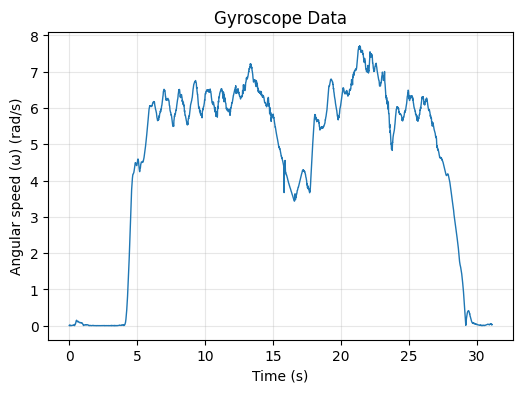

In [46]:
time = df['Time (s)']
omega = df['Absolute (rad/s)']

plt.figure(figsize=(6,4))
plt.plot(time, omega, lw=1)
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Gyroscope Data')
plt.grid(True, alpha=0.3)
plt.show()


Trimmed interval: 13.0 s to 18.0 s
Number of fitted points: 503

Summary of trimmed angular speed data:
mean    5.163213
std     1.206094
min     3.432098
max     7.219719
Name: Absolute (rad/s), dtype: float64


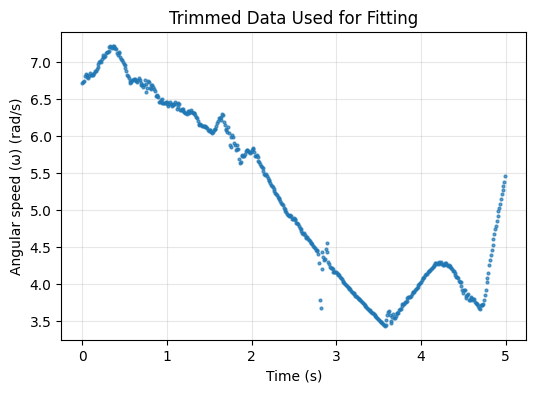

In [49]:

tStart = 13
tEnd = 18

mask = (time >= tStart) & (time <= tEnd)
time_fit = time[mask] - time[mask].iloc[0]   # reset time so fit starts at t = 0
omega_fit = omega[mask]

print(f'\nTrimmed interval: {tStart:.1f} s to {tEnd:.1f} s')
print(f'Number of fitted points: {len(time_fit)}')
print('\nSummary of trimmed angular speed data:')
print(pd.Series(omega_fit).describe()[['mean', 'std', 'min', 'max']])

plt.figure(figsize=(6,4))
plt.plot(time_fit, omega_fit, linestyle='None', marker=".", markersize=4, alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Trimmed Data Used for Fitting')
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Model Fitting (8 points)



omega_0 = 7.357 ± 0.050 rad/s
beta    = 0.152 ± 0.003 s^-1


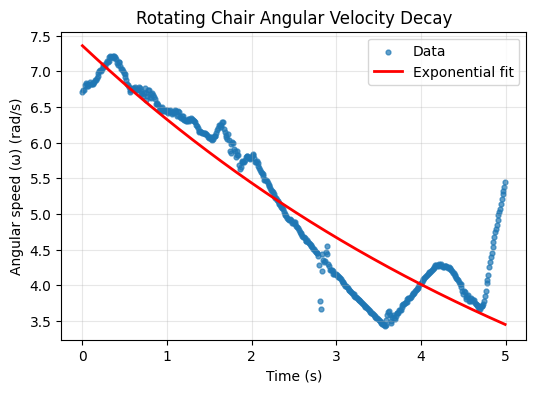

In [50]:
# Example for exponential decay (gyroscope or sound):
def Fit_curve(t, omega0, beta):
    return omega0 * np.exp(-beta * t)

p0 = [omega_fit.iloc[0], 0.2]

popt, pcov = curve_fit(Fit_curve, time_fit, omega_fit, p0=p0, maxfev=10000)
omega0_fit, beta_fit = popt
uncertainties = np.sqrt(np.diag(pcov))

omega_model = Fit_curve(time_fit, *popt)
residuals = omega_fit - omega_model

print(f"omega_0 = {omega0_fit:.3f} ± {uncertainties[0]:.3f} rad/s")
print(f"beta    = {beta_fit:.3f} ± {uncertainties[1]:.3f} s^-1")

plt.figure(figsize=(6, 4))
plt.scatter(time_fit, omega_fit, s=12, alpha=0.7, label='Data')
plt.plot(time_fit, omega_model, 'r-', linewidth=2, label='Exponential fit')
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Rotating Chair Angular Velocity Decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 4: Advanced Visualization (8 points)

### Task: Multi-Panel Figure

Create a **2×2 subplot grid**:

1. **Top-left:** Raw data vs time
2. **Top-right:** Fitted model vs time (overlay)
3. **Bottom-left:** Residuals (data - model)
4. **Bottom-right:** Histogram of residuals

**Requirements:**
- Shared x-axis (time) for top and bottom-left
- Proper axis labels with units
- Titles for each subplot
- Use `plt.subplots(2, 2, figsize=(12, 8))`

**Reference:** [Matplotlib subplots documentation](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html)

---

### Deliverable

- [ ] 2×2 figure with all four plots
- [ ] Residuals centered around zero (good fit)
- [ ] Histogram approximately Gaussian (if fit is good)

## Part 5: Error Analysis (8 points)

### Task: Uncertainty Quantification

1. **Parameter uncertainties**:
   - Extract from `curve_fit` covariance matrix: `np.sqrt(np.diag(pcov))`
   - Report fitted values ± uncertainty

2. **Sensor resolution**:
   - Check phyphox documentation or your CSV for precision
   - Example: Pressure typically ±0.1 hPa, gyroscope ±0.01 rad/s
   - How does sensor noise affect your fit?

3. **Systematic errors**:
   - **Pressure:** Local weather, sensor calibration
   - **Gyroscope:** Phone not level, chair friction varies
   - **Magnetometer:** Nearby metal objects, Earth's field
   - **Light:** Ambient light interference
   - **Microphone:** Background noise
   - **Proximity:** Non-linear sensor response

4. **Comparison to theory**:
   - Does your result match expected values?
   - Example: Barometric scale height should be ~8500 m
   - Example: Sound decay rate depends on room acoustics (no "correct" value, but should be positive)

---

### Deliverable

- [ ] Fitted parameters with uncertainties reported
- [ ] Discussion of sensor limitations (2-3 sentences)
- [ ] Comparison to expected/theoretical values (if applicable)
- [ ] List 2-3 sources of systematic error in your experiment

## Part 6: GitHub Workflow — Submit via Pull Request (10 points)

### NEW: Feature Branch Workflow (No Command Line!)

This homework introduces the **feature-branch workflow** using only the **GitHub website**. No terminal commands needed.

---

## ⚠️ IMPORTANT: Commit Messages Matter!

**You will lose points for non-descriptive commit messages.**

### Good Commit Messages ✅
- `Add data loading and preprocessing with pandas`
- `Implement exponential decay model for sound data`
- `Fix time axis trimming to remove setup period`
- `Create 2x2 subplot visualization with residuals`

### Bad Commit Messages ❌
- `update` (What did you update?)
- `fix` (What did you fix?)
- `stuff` (What stuff?)
- `asdf` (Not descriptive at all)
- `Final version` (Too vague)

### Why Commit Messages Matter:
- They document **what changed and why**
- They help reviewers understand your workflow
- They're essential in professional software development
- They help **you** remember what you did when you revisit code later

**Tip:** Write commit messages as if you're explaining to a classmate what you just did.

---

## Step-by-Step Instructions (GitHub Web Interface)

### Step 1: Go to the Repository

1. Open your browser and go to: [https://github.com/ubsuny/PHY386](https://github.com/ubsuny/PHY386)
2. Make sure you're logged into GitHub

---

### Step 2: Create Your Feature Branch

1. Click the **branch dropdown** (says "main" or "Homework2026")
2. Make sure **"Homework2026"** is selected
3. In the branch dropdown, type: `yourusername-hw3` (e.g., `jsmith-hw3`)
4. Click **"Create branch: yourusername-hw3 from Homework2026"**

![Create Branch](https://docs.github.com/assets/cb-32358/mw-1440/images/help/branches/branch-selection-dropdown.webp)

---

### Step 3: Upload Your Files

1. Make sure you're on **your branch** (check the dropdown says `yourusername-hw3`)
2. Navigate to: `2026/HW/yourusername/`
   - If your folder doesn't exist yet, create it by clicking **"Add file" → "Create new file"**
   - Name it `yourusername/.gitkeep` and commit (this creates the folder)
3. Click **"Add file" → "Upload files"**
4. Drag and drop:
   - `HW3.ipynb` (your completed notebook)
   - `yourusername_hw3_data.csv` (your raw data)
5. **At the bottom, write a DESCRIPTIVE commit message:**
   - Good: `Add HW3 notebook with gyroscope analysis and raw data`
   - Bad: `upload files`
6. Make sure **"Commit directly to yourusername-hw3 branch"** is selected
7. Click **"Commit changes"**

---

### Step 4: Open a Pull Request

1. After uploading, GitHub shows a yellow banner: **"yourusername-hw3 had recent pushes"**
2. Click the green **"Compare & pull request"** button

**OR** manually:
1. Click the **"Pull requests"** tab at the top
2. Click **"New pull request"**
3. Set:
   - **Base:** `Homework2026`
   - **Compare:** `yourusername-hw3`
4. Click **"Create pull request"**

---

### Step 5: Fill Out the PR Template

1. **Change the title** to: `HW3 - 2026 - yourusername`

2. **Fill out the description** (the template appears automatically):
   - Check **one** box under "Type of Submission":
     - `[ ]` In progress (if you want feedback)
     - `[x]` Final submission (if you're done)
   - Check all boxes in the Checklist
   - Fill in "What I implemented" section
   - Delete "Questions or notes" if you have none
   - Delete "AI Usage" if you didn't use AI

3. **Add label** (right sidebar):
   - Click **"Labels"**
   - Select: `homework-in-progress` OR `homework-final`

4. **Assign reviewer** (right sidebar):
   - Click **"Reviewers"**
   - Type: `laserlab` and select

5. **Set milestone** (right sidebar):
   - Click **"Milestone"**
   - Select: `HW3-2026`

6. Click **"Create pull request"**

---

### Step 6: Respond to Feedback

If the reviewer (in this case me) requests changes:

1. Go back to the repository
2. Switch to **your branch** (`yourusername-hw3`)
3. Navigate to your notebook file
4. Click the **pencil icon** ("Edit this file") if a text file or in google colab if a jupyter notebook
5. Make the requested changes
6. **Scroll down and commit with a DESCRIPTIVE message:**
   - Good: `Fix model function to use correct exponential form`
   - Good: `Add missing uncertainty calculations for fit parameters`
   - Bad: `fix`
7. The PR updates automatically
8. Go to your PR and **leave a comment**: "Ready for re-review @laserlab"

---

### Deliverable

- [ ] Feature branch created with correct naming (`yourusername-hw3`)
- [ ] Files uploaded to `2026/HW/yourusername/` in your branch
- [ ] **ALL commit messages are descriptive** (points will be deducted for vague messages)
- [ ] PR opened with title: `HW3 - 2026 - yourusername`
- [ ] PR template filled out completely
- [ ] Correct label added (`homework-in-progress` or `homework-final`)
- [ ] Reviewer assigned (`@laserlab`)
- [ ] Milestone set (`HW3-2026`)
- [ ] Responded to at least one round of feedback (if requested)


## Resources

- [phyphox Documentation](https://phyphox.org/)
- [phyphox Supported Sensors](https://phyphox.org/sensors/)
- [pandas Documentation](https://pandas.pydata.org/docs/)
- [scipy.optimize.curve_fit Guide](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)
- [Matplotlib Subplots](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html)
- [GitHub Pull Request Guide](https://docs.github.com/en/pull-requests/collaborating-with-pull-requests/proposing-changes-to-your-work-with-pull-requests/creating-a-pull-request)